In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT)
print("Processed-data folder:", PROCESSED_DATA_DIR)

Project root: c:\Users\PC\Documents\project-foresight
Processed-data folder: c:\Users\PC\Documents\project-foresight\data\processed


In [2]:
sales_daily = pd.read_csv(
    PROCESSED_DATA_DIR / "sales_daily.csv",
    parse_dates=["date"],
)

sku_master = pd.read_csv(
    PROCESSED_DATA_DIR / "sku_master.csv",
    parse_dates=["launch_date"],
)

inventory = pd.read_csv(
    PROCESSED_DATA_DIR / "inventory_snapshots.csv",
    parse_dates=["date"],
)

calendar = pd.read_csv(
    PROCESSED_DATA_DIR / "calendar.csv",
    parse_dates=["date"],
)

analysis = pd.read_csv(
    PROCESSED_DATA_DIR / "analysis_ready.csv",
    parse_dates=["date", "launch_date"],
)

print("sales_daily:", sales_daily.shape)
print("sku_master:", sku_master.shape)
print("inventory_snapshots:", inventory.shape)
print("calendar:", calendar.shape)
print("analysis_ready:", analysis.shape)

sales_daily: (67626, 8)
sku_master: (150, 11)
inventory_snapshots: (109650, 10)
calendar: (731, 12)
analysis_ready: (109650, 41)


In [3]:
datasets = {
    "sales_daily": sales_daily,
    "sku_master": sku_master,
    "inventory_snapshots": inventory,
    "calendar": calendar,
    "analysis_ready": analysis,
}

for name, dataframe in datasets.items():
    print("\n", name.upper())
    print("Shape:", dataframe.shape)
    print("Missing values:", dataframe.isna().sum().sum())
    print("Duplicate rows:", dataframe.duplicated().sum())


 SALES_DAILY
Shape: (67626, 8)
Missing values: 0
Duplicate rows: 0

 SKU_MASTER
Shape: (150, 11)
Missing values: 0
Duplicate rows: 0

 INVENTORY_SNAPSHOTS
Shape: (109650, 10)
Missing values: 0
Duplicate rows: 0

 CALENDAR
Shape: (731, 12)
Missing values: 0
Duplicate rows: 0

 ANALYSIS_READY
Shape: (109650, 41)
Missing values: 0
Duplicate rows: 0


In [4]:
print("Date range:")
print(analysis["date"].min(), "to", analysis["date"].max())

print("\nNumber of days:")
print(analysis["date"].nunique())

print("\nNumber of SKUs:")
print(analysis["sku_id"].nunique())

print("\nNumber of categories:")
print(analysis["category"].nunique())

print("\nCategories:")
print(sorted(analysis["category"].unique()))

Date range:
2023-01-01 00:00:00 to 2024-12-31 00:00:00

Number of days:
731

Number of SKUs:
150

Number of categories:
8

Categories:
['Apparel', 'Beauty', 'Electronics', 'Food & Bev', 'Home Decor', 'Kitchenware', 'Stationery', 'Toys']


In [5]:
total_revenue = analysis["revenue"].sum()
fulfilled_units = analysis["fulfilled_units_sold"].sum()
inventory_units = analysis["inventory_units_sold"].sum()
lost_sales_units = analysis["lost_sales"].sum()
stockout_records = analysis["stockout_flag"].sum()
promotion_records = analysis["promo_flag"].sum()

print("PROJECT FORESIGHT – CORE KPIs")
print("-" * 50)
print(f"Total revenue: {total_revenue:,.2f}")
print(f"Fulfilled units from sales data: {fulfilled_units:,.0f}")
print(f"Units sold from inventory data: {inventory_units:,.0f}")
print(f"Lost-sales units: {lost_sales_units:,.0f}")
print(f"Stockout records: {stockout_records:,.0f}")
print(f"Promotion date-SKU records: {promotion_records:,.0f}")

PROJECT FORESIGHT – CORE KPIs
--------------------------------------------------
Total revenue: 75,130,292.70
Fulfilled units from sales data: 1,552,211
Units sold from inventory data: 1,457,126
Lost-sales units: 95,085
Stockout records: 3,589
Promotion date-SKU records: 12,329


In [6]:
target_comparison = analysis[
    [
        "date",
        "sku_id",
        "fulfilled_units_sold",
        "inventory_units_sold",
        "lost_sales",
        "stockout_flag",
    ]
].copy()

target_comparison["estimated_demand"] = (
    target_comparison["inventory_units_sold"]
    + target_comparison["lost_sales"]
)

target_comparison["sales_difference"] = (
    target_comparison["fulfilled_units_sold"]
    - target_comparison["inventory_units_sold"]
)

print("TARGET COMPARISON")
print("-" * 50)

print(
    "Total fulfilled units:",
    f"{target_comparison['fulfilled_units_sold'].sum():,.0f}",
)

print(
    "Total inventory units sold:",
    f"{target_comparison['inventory_units_sold'].sum():,.0f}",
)

print(
    "Total lost sales:",
    f"{target_comparison['lost_sales'].sum():,.0f}",
)

print(
    "Total estimated demand:",
    f"{target_comparison['estimated_demand'].sum():,.0f}",
)

exact_matches = (
    target_comparison["fulfilled_units_sold"]
    == target_comparison["inventory_units_sold"]
).mean() * 100

print(f"Exact match percentage: {exact_matches:.2f}%")

correlation = target_comparison[
    [
        "fulfilled_units_sold",
        "inventory_units_sold",
    ]
].corr().iloc[0, 1]

print(f"Correlation: {correlation:.4f}")

TARGET COMPARISON
--------------------------------------------------
Total fulfilled units: 1,552,211
Total inventory units sold: 1,457,126
Total lost sales: 95,085
Total estimated demand: 1,552,211
Exact match percentage: 96.73%
Correlation: 0.9782


In [7]:
daily_summary = (
    analysis
    .groupby("date", as_index=False)
    .agg(
        fulfilled_units=("fulfilled_units_sold", "sum"),
        inventory_units_sold=("inventory_units_sold", "sum"),
        lost_sales=("lost_sales", "sum"),
        revenue=("revenue", "sum"),
        stockout_records=("stockout_flag", "sum"),
    )
)

daily_summary["estimated_demand"] = (
    daily_summary["inventory_units_sold"]
    + daily_summary["lost_sales"]
)

print("Daily summary shape:", daily_summary.shape)
display(daily_summary.head())

Daily summary shape: (731, 7)


,date,fulfilled_units,inventory_units_sold,lost_sales,revenue,stockout_records,estimated_demand
0,2023-01-01,0,0,0,0.0,0,0
1,2023-01-02,0,0,0,0.0,0,0
2,2023-01-03,0,0,0,0.0,0,0
3,2023-01-04,0,0,0,0.0,0,0
4,2023-01-05,0,0,0,0.0,0,0


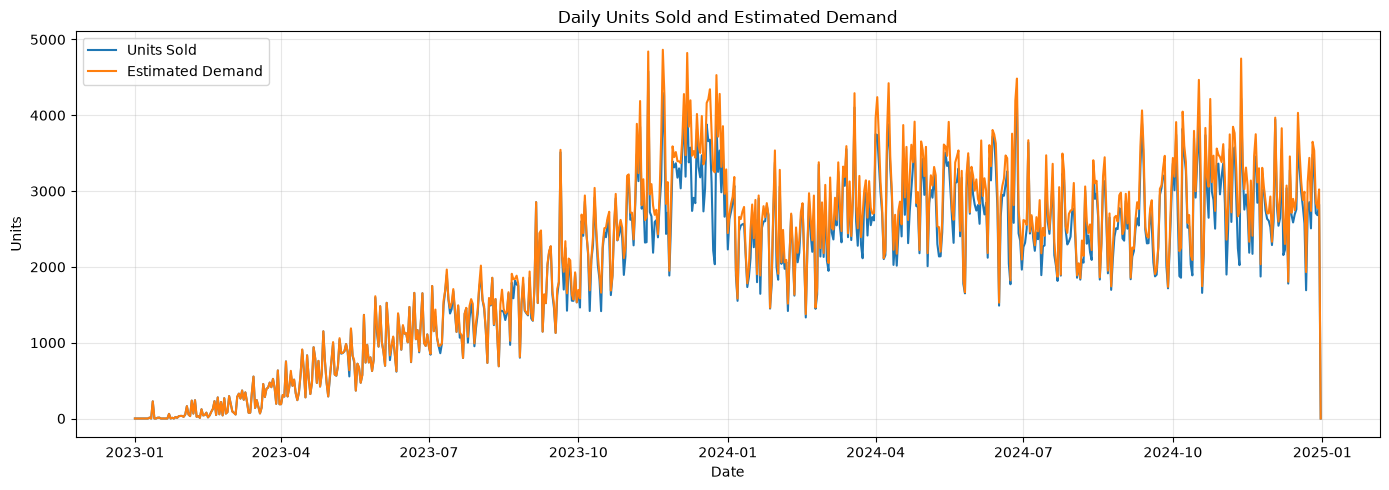

In [8]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_summary["date"],
    daily_summary["inventory_units_sold"],
    label="Units Sold",
)

plt.plot(
    daily_summary["date"],
    daily_summary["estimated_demand"],
    label="Estimated Demand",
)

plt.title("Daily Units Sold and Estimated Demand")
plt.xlabel("Date")
plt.ylabel("Units")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
demand_distribution = analysis[
    "inventory_units_sold"
].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

print("INVENTORY UNITS SOLD DISTRIBUTION")
print(demand_distribution)

zero_demand_percentage = (
    analysis["inventory_units_sold"].eq(0).mean()
    * 100
)

stockout_percentage = (
    analysis["stockout_flag"].eq(1).mean()
    * 100
)

lost_sales_percentage = (
    analysis["lost_sales"].gt(0).mean()
    * 100
)

print(
    f"\nZero-demand date-SKU records: "
    f"{zero_demand_percentage:.2f}%"
)

print(
    f"Stockout date-SKU records: "
    f"{stockout_percentage:.2f}%"
)

print(
    f"Records with lost sales: "
    f"{lost_sales_percentage:.2f}%"
)

INVENTORY UNITS SOLD DISTRIBUTION
count    109650.000000
mean         13.288883
std          43.715649
min           0.000000
25%           0.000000
50%           2.000000
75%           8.000000
90%          22.000000
95%          61.000000
99%         216.000000
max        1224.000000
Name: inventory_units_sold, dtype: float64

Zero-demand date-SKU records: 40.62%
Stockout date-SKU records: 3.27%
Records with lost sales: 3.27%


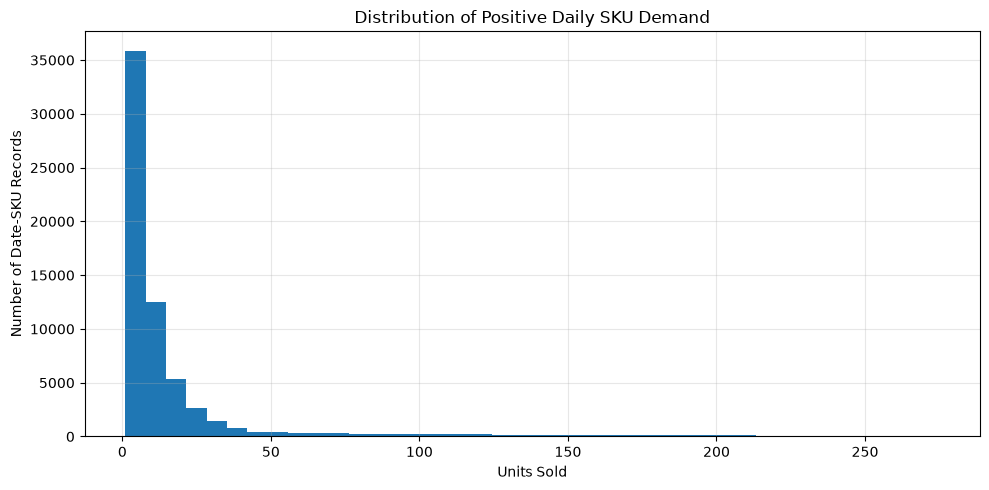

In [10]:
positive_demand = analysis.loc[
    analysis["inventory_units_sold"] > 0,
    "inventory_units_sold",
]

upper_limit = positive_demand.quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    positive_demand[
        positive_demand <= upper_limit
    ],
    bins=40,
)

plt.title("Distribution of Positive Daily SKU Demand")
plt.xlabel("Units Sold")
plt.ylabel("Number of Date-SKU Records")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
expected_demand = (
    analysis["inventory_units_sold"]
    + analysis["lost_sales"]
)

target_difference = (
    analysis["fulfilled_units_sold"]
    - expected_demand
)

print("TARGET RECONCILIATION")
print("-" * 50)

print(
    "Exact row-level matches:",
    (target_difference == 0).sum(),
)

print(
    "Mismatched rows:",
    (target_difference != 0).sum(),
)

print(
    "Maximum absolute difference:",
    target_difference.abs().max(),
)

print(
    "Total absolute difference:",
    target_difference.abs().sum(),
)

stockout_lost_sales_match = (
    analysis["stockout_flag"].eq(1)
    == analysis["lost_sales"].gt(0)
).mean() * 100

print(
    f"Stockout and lost-sales row agreement: "
    f"{stockout_lost_sales_match:.2f}%"
)

TARGET RECONCILIATION
--------------------------------------------------
Exact row-level matches: 109650
Mismatched rows: 0
Maximum absolute difference: 0
Total absolute difference: 0
Stockout and lost-sales row agreement: 100.00%


In [12]:
analysis["demand_target"] = (
    analysis["fulfilled_units_sold"]
)

print("Forecasting target created: demand_target")
print(
    "Total demand:",
    f"{analysis['demand_target'].sum():,.0f}",
)
print(
    "Missing values:",
    analysis["demand_target"].isna().sum(),
)
print(
    "Negative values:",
    (analysis["demand_target"] < 0).sum(),
)

Forecasting target created: demand_target
Total demand: 1,552,211
Missing values: 0
Negative values: 0


In [13]:
monthly_summary = (
    analysis
    .groupby(
        analysis["date"].dt.to_period("M")
    )
    .agg(
        demand=("demand_target", "sum"),
        revenue=("revenue", "sum"),
        lost_sales=("lost_sales", "sum"),
        stockouts=("stockout_flag", "sum"),
    )
    .reset_index()
)

monthly_summary["date"] = (
    monthly_summary["date"]
    .dt.to_timestamp()
)

display(monthly_summary)

,date,demand,revenue,lost_sales,stockouts
0,2023-01-01,481,26275.20,0,0
1,2023-02-01,3042,135534.67,0,0
2,2023-03-01,8637,401687.05,0,0
3,2023-04-01,15948,815780.47,61,5
4,2023-05-01,25737,1292174.05,301,17
5,2023-06-01,33238,1543651.27,165,25
6,2023-07-01,40879,2037341.25,1296,47
7,2023-08-01,46095,2178387.59,1551,82
8,2023-09-01,56816,2904748.80,1548,74
9,2023-10-01,72777,3317934.08,2992,115


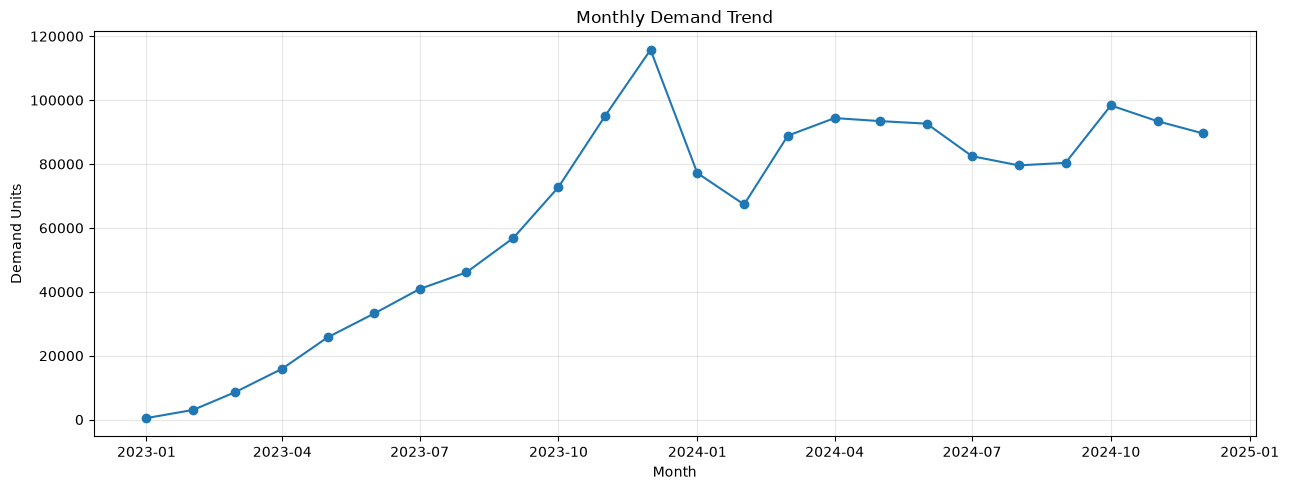

In [14]:
plt.figure(figsize=(13, 5))

plt.plot(
    monthly_summary["date"],
    monthly_summary["demand"],
    marker="o",
)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Demand Units")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
sku_performance = (
    analysis
    .groupby("sku_id", as_index=False)
    .agg(
        total_demand=("demand_target", "sum"),
        total_revenue=("revenue", "sum"),
        lost_sales=("lost_sales", "sum"),
        stockout_days=("stockout_flag", "sum"),
        active_sales_days=(
            "demand_target",
            lambda values: (values > 0).sum(),
        ),
    )
    .merge(
        sku_master[
            [
                "sku_id",
                "description",
                "category",
            ]
        ],
        on="sku_id",
        how="left",
    )
)

top_skus = sku_performance.nlargest(
    10,
    "total_demand",
)

slow_skus = sku_performance.nsmallest(
    10,
    "total_demand",
)

print("TOP 10 SKUs BY DEMAND")
display(top_skus)

print("SLOWEST 10 SKUs BY DEMAND")
display(slow_skus)

TOP 10 SKUs BY DEMAND


,sku_id,total_demand,total_revenue,lost_sales,stockout_days,active_sales_days,description,category
100,SKU10100,206723,9738140.99,2831,14,708,BELT LEATHER BLACK,Apparel
144,SKU10144,114568,1961819.11,624,10,701,SPICE MIX CURRY,Food & Bev
45,SKU10045,93410,2755633.12,2682,18,692,CASSEROLE DISH OVAL,Kitchenware
105,SKU10105,62654,13307808.07,2602,15,681,BLUETOOTH SPEAKER PORTABLE,Electronics
21,SKU10021,60172,555089.35,1637,11,684,WIND CHIME BAMBOO,Home Decor
114,SKU10114,54215,13255687.34,1678,17,686,LED BULB SMART,Electronics
143,SKU10143,31146,774713.25,621,11,666,SAUCE BOTTLE TOMATO,Food & Bev
47,SKU10047,30563,65422.77,1814,26,666,PACK OF 72 RETROSPOT CAKE CASES,Stationery
123,SKU10123,30563,194757.53,2243,33,669,SHAMPOO HERBAL,Beauty
103,SKU10103,30254,2193548.62,1280,19,656,SLIPPERS HOUSE,Apparel


SLOWEST 10 SKUs BY DEMAND


,sku_id,total_demand,total_revenue,lost_sales,stockout_days,active_sales_days,description,category
104,SKU10104,409,29481.27,0,0,129,PYJAMA SET COTTON,Apparel
41,SKU10041,465,5731.59,52,1,121,BREAD BIN METAL,Kitchenware
88,SKU10088,624,23372.55,11,5,129,LUNCH BAG SPACEBOY DESIGN,Apparel
5,SKU10005,667,5534.03,6,3,172,WOODEN PHOTO FRAME,Home Decor
98,SKU10098,720,31274.40,19,5,136,BACKPACK CASUAL,Apparel
62,SKU10062,772,10839.76,109,1,201,SCISSORS OFFICE,Stationery
134,SKU10134,801,10573.47,24,1,111,FOUNDATION LIQUID,Beauty
149,SKU10149,808,10066.16,187,4,168,HERBAL TEA CHAMOMILE,Food & Bev
121,SKU10121,859,7380.16,84,6,192,LIP BALM NATURAL,Beauty
4,SKU10004,939,14987.79,92,9,185,WALL MIRROR ROUND,Home Decor


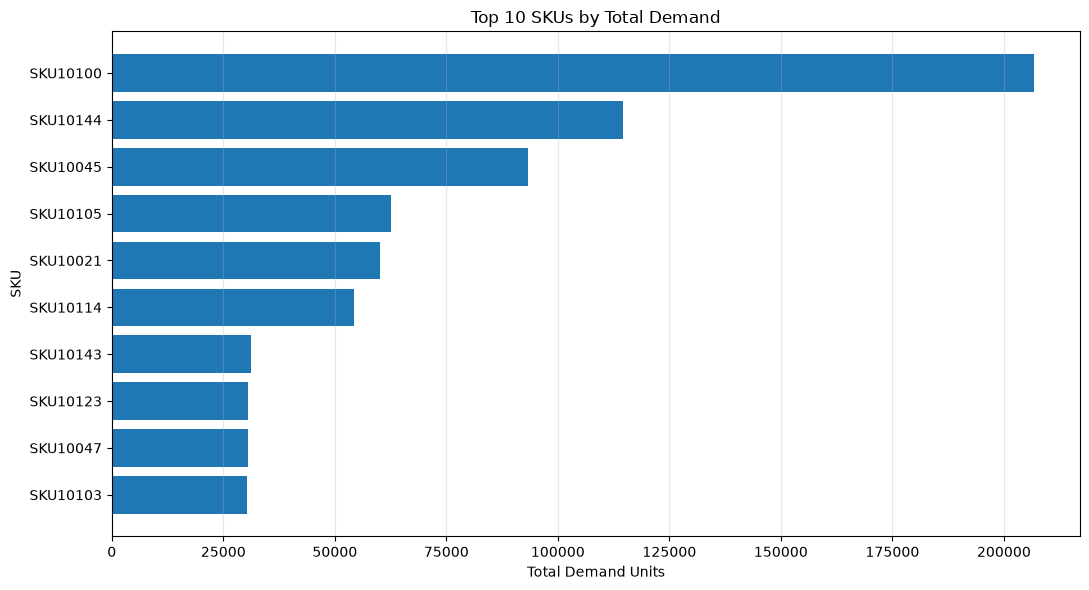

In [16]:
top_skus_plot = top_skus.sort_values(
    "total_demand",
    ascending=True,
)

plt.figure(figsize=(11, 6))

plt.barh(
    top_skus_plot["sku_id"],
    top_skus_plot["total_demand"],
)

plt.title("Top 10 SKUs by Total Demand")
plt.xlabel("Total Demand Units")
plt.ylabel("SKU")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

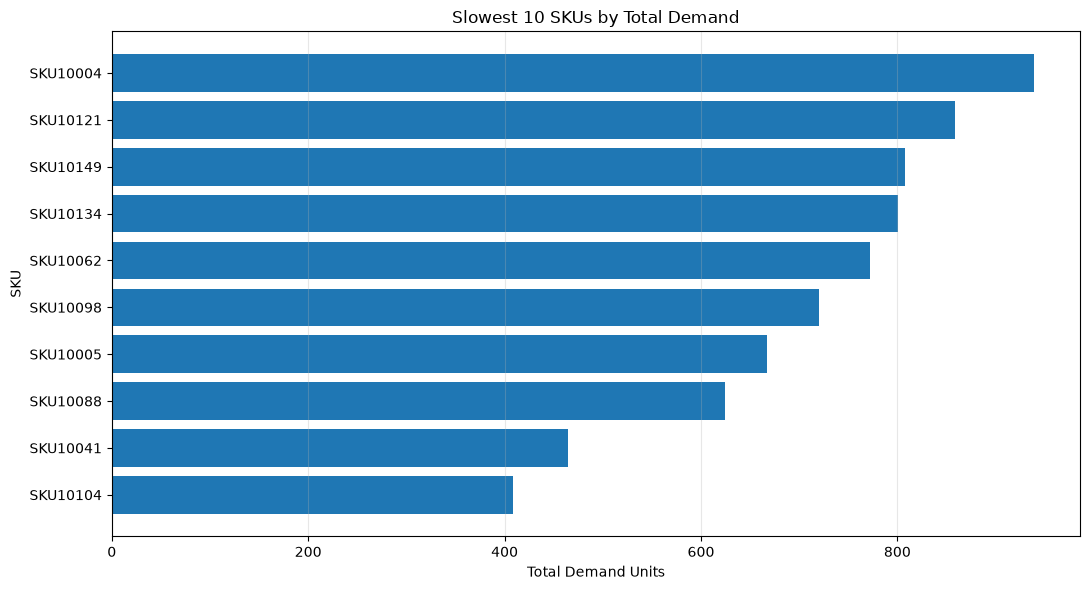

In [17]:
slow_skus_plot = slow_skus.sort_values(
    "total_demand",
    ascending=True,
)

plt.figure(figsize=(11, 6))

plt.barh(
    slow_skus_plot["sku_id"],
    slow_skus_plot["total_demand"],
)

plt.title("Slowest 10 SKUs by Total Demand")
plt.xlabel("Total Demand Units")
plt.ylabel("SKU")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
latest_date = analysis["date"].max()
dead_stock_start = latest_date - pd.Timedelta(weeks=13)

recent_demand = (
    analysis.loc[
        analysis["date"] > dead_stock_start
    ]
    .groupby("sku_id", as_index=False)
    .agg(
        recent_13_week_demand=(
            "demand_target",
            "sum",
        )
    )
)

latest_inventory = (
    analysis
    .sort_values("date")
    .groupby(
        "sku_id",
        as_index=False,
    )
    .tail(1)
    [
        [
            "sku_id",
            "category",
            "on_hand_units",
            "unit_cost",
        ]
    ]
)

dead_stock_analysis = latest_inventory.merge(
    recent_demand,
    on="sku_id",
    how="left",
)

dead_stock_analysis[
    "recent_13_week_demand"
] = dead_stock_analysis[
    "recent_13_week_demand"
].fillna(0)

dead_stock_analysis[
    "capital_tied_up"
] = (
    dead_stock_analysis["on_hand_units"]
    * dead_stock_analysis["unit_cost"]
)

dead_stock = dead_stock_analysis.loc[
    (
        dead_stock_analysis[
            "recent_13_week_demand"
        ] == 0
    )
    & (
        dead_stock_analysis[
            "on_hand_units"
        ] > 0
    )
].copy()

dead_stock = dead_stock.sort_values(
    "capital_tied_up",
    ascending=False,
)

print(
    "Dead-stock definition: "
    "positive ending inventory with zero demand "
    "during the latest 13 weeks."
)

print("Latest date:", latest_date.date())
print("Analysis start:", dead_stock_start.date())
print("Dead-stock SKUs:", len(dead_stock))
print(
    "Dead-stock units:",
    int(dead_stock["on_hand_units"].sum()),
)
print(
    "Capital tied up:",
    round(dead_stock["capital_tied_up"].sum(), 2),
)

display(dead_stock.head(10))

Dead-stock definition: positive ending inventory with zero demand during the latest 13 weeks.
Latest date: 2024-12-31
Analysis start: 2024-10-01
Dead-stock SKUs: 0
Dead-stock units: 0
Capital tied up: 0.0


,sku_id,category,on_hand_units,unit_cost,recent_13_week_demand,capital_tied_up


In [19]:
category_performance = (
    analysis
    .groupby("category", as_index=False)
    .agg(
        total_demand=("demand_target", "sum"),
        total_revenue=("revenue", "sum"),
        lost_sales=("lost_sales", "sum"),
        stockout_days=("stockout_flag", "sum"),
        unique_skus=("sku_id", "nunique"),
    )
)

category_performance["lost_sales_rate"] = (
    category_performance["lost_sales"]
    / category_performance["total_demand"]
    * 100
)

category_performance = category_performance.sort_values(
    "total_demand",
    ascending=False,
)

display(category_performance)

,category,total_demand,total_revenue,lost_sales,stockout_days,unique_skus,lost_sales_rate
0,Apparel,369475,17343434.69,11448,288,20,3.098451
3,Food & Bev,240984,4455624.20,10112,260,15,4.196129
4,Home Decor,209788,2604131.08,17093,726,25,8.147749
2,Electronics,208871,40640605.65,12336,409,15,5.906038
5,Kitchenware,191016,5362608.98,12431,580,22,6.507832
6,Stationery,152317,1027186.24,14035,435,20,9.214336
7,Toys,94594,1933814.74,8725,496,18,9.223629
1,Beauty,85166,1762887.12,8905,395,15,10.456051


In [20]:
driver_columns = [
    "demand_target",
    "promo_flag",
    "effective_unit_price",
    "on_hand_units",
    "on_order_units",
    "stockout_flag",
    "lost_sales",
    "reorder_point",
    "inventory_position",
]

available_driver_columns = [
    column
    for column in driver_columns
    if column in analysis.columns
]

driver_correlation = (
    analysis[available_driver_columns]
    .corr(method="spearman")
)

demand_driver_correlation = (
    driver_correlation["demand_target"]
    .drop("demand_target")
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False,
    )
    .rename("spearman_correlation")
    .reset_index()
    .rename(columns={"index": "driver"})
)

print("Spearman correlations with demand:")
display(demand_driver_correlation)

Spearman correlations with demand:


,driver,spearman_correlation
0,inventory_position,0.475270
1,on_order_units,0.474567
2,promo_flag,0.409450
3,reorder_point,0.401692
4,lost_sales,0.176667
5,stockout_flag,0.174624
6,on_hand_units,0.166934
7,effective_unit_price,0.048776


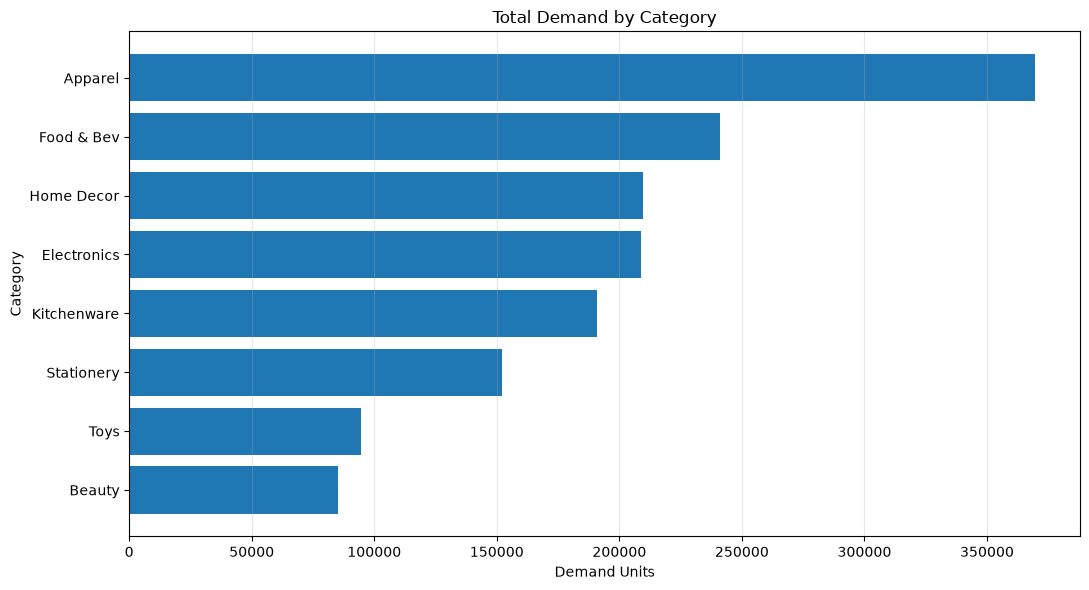

In [21]:
category_plot = category_performance.sort_values(
    "total_demand",
    ascending=True,
)

plt.figure(figsize=(11, 6))

plt.barh(
    category_plot["category"],
    category_plot["total_demand"],
)

plt.title("Total Demand by Category")
plt.xlabel("Demand Units")
plt.ylabel("Category")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
stockout_risk = (
    sku_performance
    .sort_values(
        ["stockout_days", "lost_sales"],
        ascending=False,
    )
    .head(10)
)

print("TOP 10 SKUs BY STOCKOUT DAYS")
display(stockout_risk)

TOP 10 SKUs BY STOCKOUT DAYS


,sku_id,total_demand,total_revenue,lost_sales,stockout_days,active_sales_days,description,category
9,SKU10009,4866,71353.56,779,56,523,CUSHION COVER VINTAGE,Home Decor
28,SKU10028,4862,134379.70,651,55,498,IVORY KNITTED MUG COSY,Kitchenware
109,SKU10109,8322,2018955.36,1118,53,583,PHONE CASE SILICONE,Electronics
120,SKU10120,11152,468169.36,1891,52,607,FACE CREAM MOISTURIZING,Beauty
11,SKU10011,4827,11106.97,752,52,526,WALL CLOCK ROMAN,Home Decor
44,SKU10044,6289,194676.63,1094,51,530,TEAPOT CERAMIC,Kitchenware
63,SKU10063,10602,119347.78,1290,50,600,TAPE DISPENSER,Stationery
82,SKU10082,22035,226157.30,1997,48,665,WOODEN TRAIN SET,Toys
129,SKU10129,5362,126401.73,759,47,500,FACE MASK PACK 5,Beauty
18,SKU10018,4059,45987.07,701,47,427,LAMP SHADE FABRIC,Home Decor


In [23]:
stockout_summary = (
    analysis
    .groupby("stockout_flag", as_index=False)
    .agg(
        records=("sku_id", "size"),
        total_demand=("demand_target", "sum"),
        units_sold=("inventory_units_sold", "sum"),
        lost_sales=("lost_sales", "sum"),
    )
)

stockout_summary["average_lost_sales"] = (
    stockout_summary["lost_sales"]
    / stockout_summary["records"]
)

display(stockout_summary)

,stockout_flag,records,total_demand,units_sold,lost_sales,average_lost_sales
0,0,106061,1360012,1360012,0,0.000000
1,1,3589,192199,97114,95085,26.493452


In [24]:
promotion_summary = (
    analysis
    .groupby("promo_flag", as_index=False)
    .agg(
        records=("sku_id", "size"),
        total_demand=("demand_target", "sum"),
        average_daily_demand=("demand_target", "mean"),
        total_revenue=("revenue", "sum"),
    )
)

promotion_summary["promo_status"] = promotion_summary[
    "promo_flag"
].map(
    {
        0: "No Promotion",
        1: "Promotion",
    }
)

display(
    promotion_summary[
        [
            "promo_status",
            "records",
            "total_demand",
            "average_daily_demand",
            "total_revenue",
        ]
    ]
)

promo_average = promotion_summary.loc[
    promotion_summary["promo_flag"] == 1,
    "average_daily_demand",
].iloc[0]

non_promo_average = promotion_summary.loc[
    promotion_summary["promo_flag"] == 0,
    "average_daily_demand",
].iloc[0]

promotion_uplift_percent = (
    (promo_average - non_promo_average)
    / non_promo_average
    * 100
)

print(
    "Average demand during promotions:",
    round(promo_average, 2),
)

print(
    "Average demand without promotions:",
    round(non_promo_average, 2),
)

print(
    "Observed promotion demand difference:",
    f"{promotion_uplift_percent:.2f}%",
)

,promo_status,records,total_demand,average_daily_demand,total_revenue
0,No Promotion,97321,800051,8.220744,34300023.52
1,Promotion,12329,752160,61.007381,40830269.18


Average demand during promotions: 61.01
Average demand without promotions: 8.22
Observed promotion demand difference: 642.12%


In [25]:
weekday_summary = (
    analysis
    .groupby(
        ["day_of_week", "day_name"],
        as_index=False,
    )
    .agg(
        total_demand=("demand_target", "sum"),
        average_demand=("demand_target", "mean"),
        lost_sales=("lost_sales", "sum"),
    )
    .sort_values("day_of_week")
)

display(weekday_summary)


,day_of_week,day_name,total_demand,average_demand,lost_sales
0,0,Monday,233664,14.835810,15003
1,1,Tuesday,242229,15.379619,13763
2,2,Wednesday,233528,14.969744,13543
3,3,Thursday,240870,15.440385,13393
4,4,Friday,223525,14.328526,13626
5,5,Saturday,197451,12.657115,12423
6,6,Sunday,180944,11.488508,13334


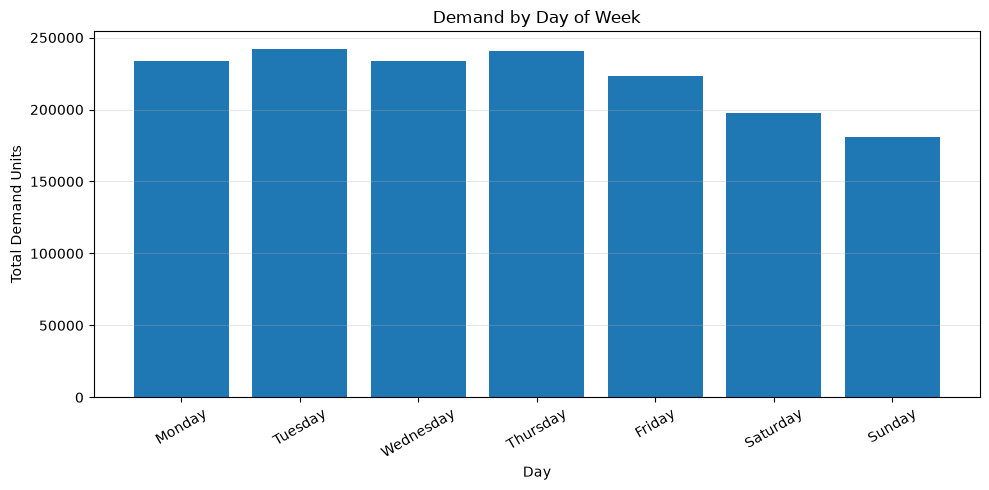

In [26]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_summary["day_name"],
    weekday_summary["total_demand"],
)

plt.title("Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Demand Units")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
month_summary = (
    analysis
    .groupby(
        ["month", "month_name"],
        as_index=False,
    )
    .agg(
        total_demand=("demand_target", "sum"),
        average_demand=("demand_target", "mean"),
        lost_sales=("lost_sales", "sum"),
        stockout_days=("stockout_flag", "sum"),
    )
    .sort_values("month")
)

display(month_summary)

,month,month_name,total_demand,average_demand,lost_sales,stockout_days
0,1,January,77656,8.350108,3762,177
1,2,February,70383,8.231930,2664,117
2,3,March,97535,10.487634,5074,221
3,4,April,110338,12.259778,6923,204
4,5,May,119175,12.814516,5948,252
5,6,June,125883,13.987000,7358,258
6,7,July,123342,13.262581,5883,238
7,8,August,125681,13.514086,5641,255
8,9,September,137190,15.243333,5338,241
9,10,October,171125,18.400538,9895,391


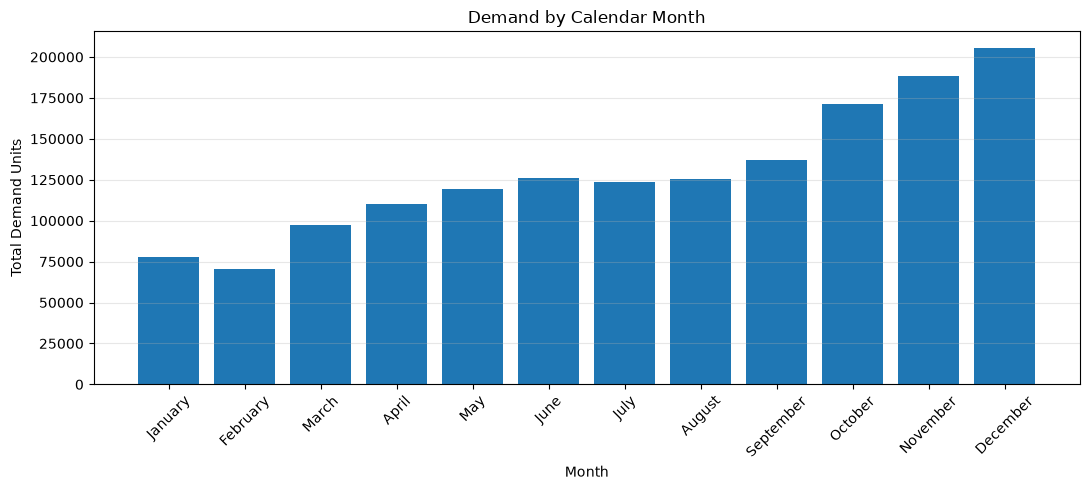

In [28]:
plt.figure(figsize=(11, 5))

plt.bar(
    month_summary["month_name"],
    month_summary["total_demand"],
)

plt.title("Demand by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Total Demand Units")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
monthly_by_year = (
    analysis
    .groupby(
        ["year", "month", "month_name"],
        as_index=False,
    )
    .agg(
        total_demand=("demand_target", "sum"),
        lost_sales=("lost_sales", "sum"),
        stockout_days=("stockout_flag", "sum"),
    )
    .sort_values(["year", "month"])
)

display(monthly_by_year)


,year,month,month_name,total_demand,lost_sales,stockout_days
0,2023,1,January,481,0,0
1,2023,2,February,3042,0,0
2,2023,3,March,8637,0,0
3,2023,4,April,15948,61,5
4,2023,5,May,25737,301,17
5,2023,6,June,33238,165,25
6,2023,7,July,40879,1296,47
7,2023,8,August,46095,1551,82
8,2023,9,September,56816,1548,74
9,2023,10,October,72777,2992,115


In [30]:
monthly_pivot = monthly_by_year.pivot(
    index="month",
    columns="year",
    values="total_demand",
)

monthly_pivot.index = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

display(monthly_pivot)

year,2023,2024
Jan,481,77175
Feb,3042,67341
Mar,8637,88898
Apr,15948,94390
May,25737,93438
Jun,33238,92645
Jul,40879,82463
Aug,46095,79586
Sep,56816,80374
Oct,72777,98348


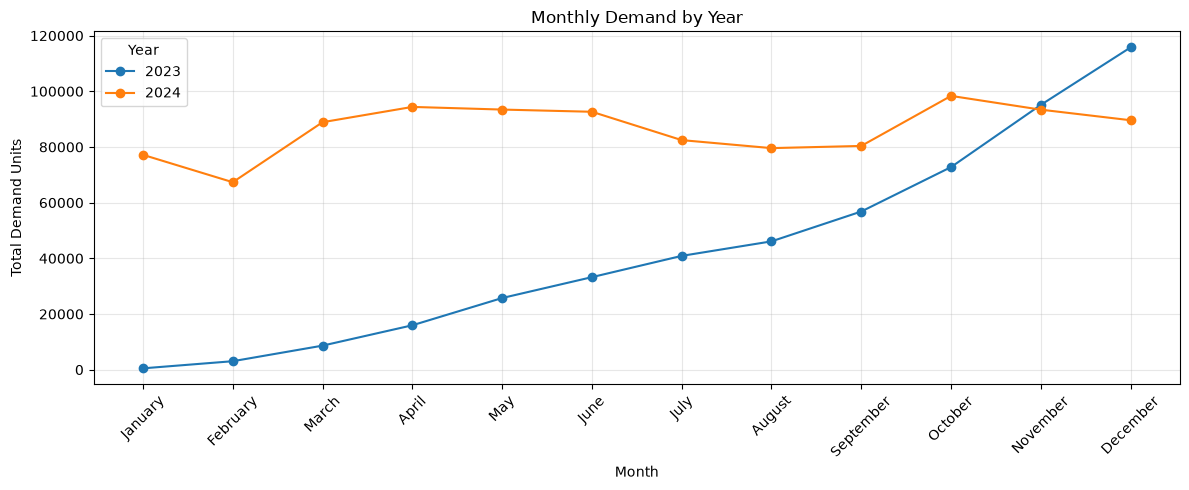

In [31]:
plt.figure(figsize=(12, 5))

for year in sorted(monthly_by_year["year"].unique()):
    year_data = monthly_by_year[
        monthly_by_year["year"] == year
    ]

    plt.plot(
        year_data["month_name"],
        year_data["total_demand"],
        marker="o",
        label=str(year),
    )

plt.title("Monthly Demand by Year")
plt.xlabel("Month")
plt.ylabel("Total Demand Units")
plt.xticks(rotation=45)
plt.legend(title="Year")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
yearly_summary = (
    analysis
    .groupby("year", as_index=False)
    .agg(
        total_demand=("demand_target", "sum"),
        total_revenue=("revenue", "sum"),
        lost_sales=("lost_sales", "sum"),
        stockout_days=("stockout_flag", "sum"),
    )
)

yearly_summary["lost_sales_rate"] = (
    yearly_summary["lost_sales"]
    / yearly_summary["total_demand"]
    * 100
)

display(yearly_summary)

,year,total_demand,total_revenue,lost_sales,stockout_days,lost_sales_rate
0,2023,514550,25088963.59,30211,1069,5.871344
1,2024,1037661,50041329.11,64874,2520,6.251945


In [33]:
year_comparison = monthly_by_year.pivot(
    index=["month", "month_name"],
    columns="year",
    values="total_demand",
).reset_index()

year_columns = sorted(
    monthly_by_year["year"].unique()
)

if len(year_columns) == 2:
    first_year = year_columns[0]
    second_year = year_columns[1]

    year_comparison["growth_percentage"] = (
        (
            year_comparison[second_year]
            - year_comparison[first_year]
        )
        / year_comparison[first_year]
        * 100
    )

display(year_comparison)

year,month,month_name,2023,2024,growth_percentage
0,1,January,481,77175,15944.698545
1,2,February,3042,67341,2113.708087
2,3,March,8637,88898,929.269422
3,4,April,15948,94390,491.861048
4,5,May,25737,93438,263.049306
5,6,June,33238,92645,178.732174
6,7,July,40879,82463,101.724602
7,8,August,46095,79586,72.656470
8,9,September,56816,80374,41.463672
9,10,October,72777,98348,35.136101


In [34]:
sku_concentration = (
    sku_performance
    .sort_values(
        "total_demand",
        ascending=False,
    )
    .reset_index(drop=True)
)

sku_concentration["demand_share"] = (
    sku_concentration["total_demand"]
    / sku_concentration["total_demand"].sum()
    * 100
)

sku_concentration["cumulative_demand_share"] = (
    sku_concentration["demand_share"]
    .cumsum()
)

top_10_share = (
    sku_concentration
    .head(10)["demand_share"]
    .sum()
)

top_20_share = (
    sku_concentration
    .head(20)["demand_share"]
    .sum()
)

print(
    f"Top 10 SKUs demand share: "
    f"{top_10_share:.2f}%"
)

print(
    f"Top 20 SKUs demand share: "
    f"{top_20_share:.2f}%"
)

display(
    sku_concentration[
        [
            "sku_id",
            "description",
            "category",
            "total_demand",
            "demand_share",
            "cumulative_demand_share",
        ]
    ].head(20)
)

Top 10 SKUs demand share: 46.02%
Top 20 SKUs demand share: 59.75%


,sku_id,description,category,total_demand,demand_share,cumulative_demand_share
0,SKU10100,BELT LEATHER BLACK,Apparel,206723,13.317970,13.317970
1,SKU10144,SPICE MIX CURRY,Food & Bev,114568,7.380955,20.698926
2,SKU10045,CASSEROLE DISH OVAL,Kitchenware,93410,6.017867,26.716793
3,SKU10105,BLUETOOTH SPEAKER PORTABLE,Electronics,62654,4.036436,30.753229
4,SKU10021,WIND CHIME BAMBOO,Home Decor,60172,3.876535,34.629764
5,SKU10114,LED BULB SMART,Electronics,54215,3.492760,38.122523
6,SKU10143,SAUCE BOTTLE TOMATO,Food & Bev,31146,2.006557,40.129080
7,SKU10123,SHAMPOO HERBAL,Beauty,30563,1.968998,42.098078
8,SKU10047,PACK OF 72 RETROSPOT CAKE CASES,Stationery,30563,1.968998,44.067076
9,SKU10103,SLIPPERS HOUSE,Apparel,30254,1.949091,46.016167


In [35]:
sku_variability = (
    analysis
    .groupby("sku_id", as_index=False)
    .agg(
        total_demand=("demand_target", "sum"),
        average_daily_demand=("demand_target", "mean"),
        demand_std=("demand_target", "std"),
        zero_demand_days=(
            "demand_target",
            lambda values: (values == 0).sum(),
        ),
        observed_days=("demand_target", "size"),
    )
)

sku_variability["zero_demand_rate"] = (
    sku_variability["zero_demand_days"]
    / sku_variability["observed_days"]
    * 100
)

sku_variability["coefficient_of_variation"] = (
    sku_variability["demand_std"]
    / sku_variability["average_daily_demand"]
)

sku_variability = sku_variability.merge(
    sku_master[
        [
            "sku_id",
            "description",
            "category",
        ]
    ],
    on="sku_id",
    how="left",
)

most_intermittent = (
    sku_variability
    .sort_values(
        [
            "zero_demand_rate",
            "coefficient_of_variation",
        ],
        ascending=False,
    )
    .head(10)
)

print("MOST INTERMITTENT SKUs")
display(most_intermittent)

MOST INTERMITTENT SKUs


,sku_id,total_demand,average_daily_demand,demand_std,zero_demand_days,observed_days,zero_demand_rate,coefficient_of_variation,description,category
134,SKU10134,801,1.095759,9.224097,620,731,84.815321,8.417996,FOUNDATION LIQUID,Beauty
41,SKU10041,465,0.636115,4.678603,610,731,83.447332,7.354965,BREAD BIN METAL,Kitchenware
88,SKU10088,624,0.853625,6.613947,602,731,82.352941,7.748070,LUNCH BAG SPACEBOY DESIGN,Apparel
104,SKU10104,409,0.559508,1.616762,602,731,82.352941,2.889616,PYJAMA SET COTTON,Apparel
98,SKU10098,720,0.984952,8.333859,595,731,81.395349,8.461181,BACKPACK CASUAL,Apparel
27,SKU10027,1398,1.912449,14.153096,591,731,80.848153,7.400510,JAM MAKING SET WITH JARS,Kitchenware
95,SKU10095,1017,1.391245,9.291335,574,731,78.522572,6.678433,HOODIE FLEECE,Apparel
97,SKU10097,1256,1.718194,12.585159,566,731,77.428181,7.324643,UMBRELLA COMPACT,Apparel
58,SKU10058,1152,1.575923,12.054360,565,731,77.291382,7.649077,DIARY HARDCOVER,Stationery
149,SKU10149,808,1.105335,7.058356,563,731,77.017784,6.385716,HERBAL TEA CHAMOMILE,Food & Bev


In [36]:
print("SKU DEMAND VARIABILITY SUMMARY")
print("-" * 50)

print(
    "Median zero-demand rate:",
    f"{sku_variability['zero_demand_rate'].median():.2f}%",
)

print(
    "SKUs with more than 50% zero-demand days:",
    (
        sku_variability["zero_demand_rate"] > 50
    ).sum(),
)

print(
    "SKUs with coefficient of variation above 1:",
    (
        sku_variability[
            "coefficient_of_variation"
        ] > 1
    ).sum(),
)

print(
    "SKUs with coefficient of variation above 2:",
    (
        sku_variability[
            "coefficient_of_variation"
        ] > 2
    ).sum(),
)

SKU DEMAND VARIABILITY SUMMARY
--------------------------------------------------
Median zero-demand rate: 33.52%
SKUs with more than 50% zero-demand days: 42
SKUs with coefficient of variation above 1: 146
SKUs with coefficient of variation above 2: 121
